# Partea 1 – Analiza si intelegerea setului de date
## Dataset: Australian Credit Approval (UCI)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




## 1. Descrierea generala a setului de date si a variabilei tinta

Sursa:[Australian Credit Approval](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Australian+Credit+Approval%29)

Scopul problemei: Prezicerea daca o cerere de credit este aprobata sau respinsa pe baza unor caracteristici personale si financiare. Variabila tinta este **A15**.

Tipul problemei: Clasificare binara (0 = respins, 1 = aprobat)

Numarul de trasaturi:690
Tipul trasaturilor:

| Variable Name | Role    | Type        | Missing Values |
|---------------|---------|-------------|----------------|
| A1            | Feature | Categorical | no             |
| A2            | Feature | Continuous  | no             |  
| A3            | Feature | Continuous  | no             |
| A4            | Feature | Categorical | no             |
| A5            | Feature | Categorical | no             |
| A6            | Feature | Categorical | no             |
| A7            | Feature | Continuous  | no             |
| A8            | Feature | Categorical | no             |
| A9            | Feature | Categorical | no             |
| A10           | Feature | Continuous  | no             |
| A11           | Feature | Categorical | no             |
| A12           | Feature | Categorical | no             |
| A13           | Feature | Continuous  | no             |
| A14           | Feature | Continuous  | no             |
| A15           | Target  | Categorical | no             |

In [6]:
# Citirea setului de date
col_names = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15']
df = pd.read_csv('australian.dat', sep=' ', header=None, names=col_names)

# Numarul de instante si trasaturi
n_instante, n_trasaturi = df.shape
print(f"Numar de randuri: {n_instante}")
print(f"Numar de trasaturi fara target: {n_trasaturi - 1}\n")
print("Primele 5 randuri:")
df.head()

Numar de randuri: 690
Numar de trasaturi fara target: 14

Primele 5 randuri:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1



## 2. Distributia claselor

In [3]:
class_counts = df['A15'].value_counts().sort_index()
# print(class_counts)
# print(class_counts.sum())
class_pct = class_counts/class_counts.sum() * 100

dist = pd.DataFrame({

    'Nr. instante': class_counts.values,
    'Procent (%)': class_pct.values.round(2)
})
print("Distributia claselor:")
print(dist)

Distributia claselor:
   Nr. instante  Procent (%)
0           383        55.51
1           307        44.49


C:\Users\Tavi\AppData\Local\Temp\ipykernel_20988\2997662741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='A15', data=df, palette='Set1', ax=axes[0])
C:\Users\Tavi\AppData\Local\Temp\ipykernel_20988\2997662741.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['0 (Respins)', '1 (Aprobat)'])


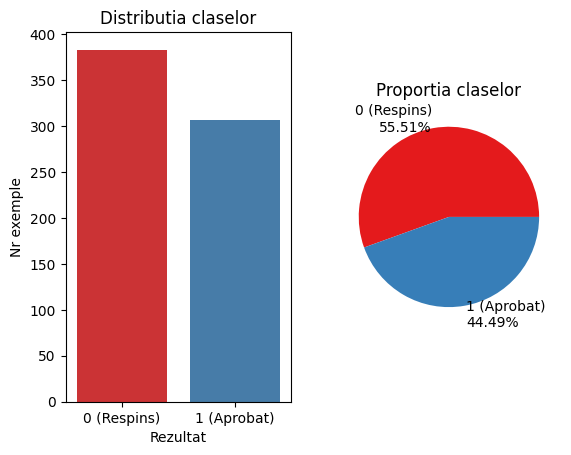

Dataset-ul este relativ echilibrat:
   clasa 0: 55.51%, clasa 1: 44.49%


In [ ]:

fig, axes = plt.subplots(1, 2)

# Countplot
sns.countplot(x='A15', data=df, palette='Set1', ax=axes[0])  #echivalent cu .bar da arata mai bine
axes[0].set_title('Distributia claselor')
axes[0].set_xlabel('Rezultat')
axes[0].set_ylabel('Nr exemple')
axes[0].set_xticklabels(['0 (Respins)', '1 (Aprobat)'])


# Pie chart
axes[1].pie(class_counts.values, labels= [f'0 (Respins)\n{class_pct[0].round(2)}%', f'1 (Aprobat)\n{class_pct[1].round(2)}%'],
            colors=sns.color_palette('Set1'))
axes[1].set_title('Proportia claselor')

plt.show()

print("Dataset-ul este relativ echilibrat:")
print(f"   clasa 0: {class_pct[0]:.2f}%, clasa 1: {class_pct[1]:.2f}%")


## 3. Identificarea valorilor lipsa si a problemelor de calitate

In [5]:
missing = df.isnull().sum()
# print(df.isnull())
# print(missing)
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({'Nr. valori lipsa': missing, 'Procent (%)': missing_pct.round(2)})
print("Valori lipsa per trasatura:")
print(missing_table)
print(f"\nTotal valori lipsa: {missing.sum()}")

Valori lipsa per trasatura:
     Nr. valori lipsa  Procent (%)
A1                  0          0.0
A2                  0          0.0
A3                  0          0.0
A4                  0          0.0
A5                  0          0.0
A6                  0          0.0
A7                  0          0.0
A8                  0          0.0
A9                  0          0.0
A10                 0          0.0
A11                 0          0.0
A12                 0          0.0
A13                 0          0.0
A14                 0          0.0
A15                 0          0.0

Total valori lipsa: 0


In [6]:
n_dup = df.duplicated().sum()
pct_dup = (n_dup / len(df)) * 100
print(f"Numar de randuri duplicate: {n_dup}")

Numar de randuri duplicate: 0


### Cazul in care ar fi existat valori lipsa/duplicate:

In [7]:
df_copy = df.copy()

# Eliminare duplicate
if n_dup > 0:
    df_copy = df_copy.drop_duplicates()
    print(f"Randuri duplicate eliminate: {n_dup}")

num_cols = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']
cat_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']


#In cazul in care lipsesc valori numerice putem pune valoarea mediana nefiind afectata de outliers atat de mult
for col in num_cols:
    if df_copy[col].isnull().sum() > 0:
        median_val = df_copy[col].median()
        df_copy[col] = df_copy[col].fillna(median_val)
        print(f"  {col}: inlocuit cu mediana ({median_val})")


#In cazul in care lipsesc mai multe valori categorice care ar putea face diferenta mai mult putem opta 
# intre a pune valoarea cea mai comuna din categoria respectiva sau daca 
# dataset ul ne permite fiind destul de mare,sa stergem complet randul
if len(df_copy) > 1000:
    df_copy = df_copy.dropna(subset=cat_cols,thresh=len(cat_cols)/2)
else:
    for col in cat_cols:
        if df_copy[col].isnull().sum() > 0:
            mode_val = df_copy[col].mode()[0]
            df_copy[col] = df_copy[col].fillna(mode_val)
            print(f" {col}: inlocuit cu ({mode_val})")

# df_copy.to_csv("australian_clean.dat", sep=" ", header=False, index=False)
df_clean=df_copy

## 4a. Analiza trasaturilor numerice

In [30]:

num_cols = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']
stats = df_clean[num_cols].describe().T
stats = stats.round(3)
print("Statistici descriptive:")
print(stats)

Statistici descriptive:
     count      mean       std    min     25%      50%      75%        max
A2   690.0    31.568    11.853  13.75  22.670   28.625   37.707      80.25
A3   690.0     4.759     4.978   0.00   1.000    2.750    7.208      28.00
A7   690.0     2.223     3.347   0.00   0.165    1.000    2.625      28.50
A10  690.0     2.400     4.863   0.00   0.000    0.000    3.000      67.00
A13  690.0   184.014   172.159   0.00  80.000  160.000  272.000    2000.00
A14  690.0  1018.386  5210.103   1.00   1.000    6.000  396.500  100001.00


### Afisare histograma pentru trasaturile cu cea mai mare deviatie standard 


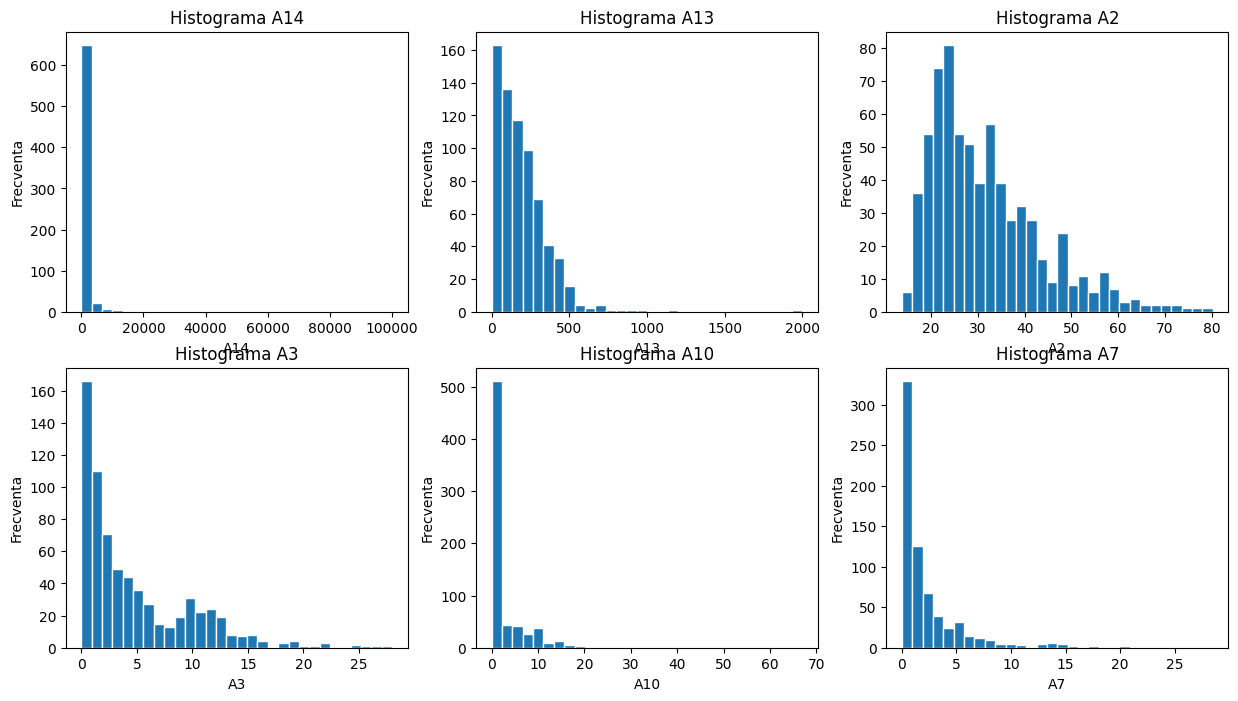

In [15]:
deviatii = df_clean[num_cols].std()
# print(deviatii)
deviatii_sortate = deviatii.sort_values(ascending=False)
# print(deviatii_sortate)
coloane_de_afisat = deviatii_sortate.head(15).index
# print(coloane_de_afisat)
numar_grafice = len(coloane_de_afisat)


fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = np.array(axes).flatten() 

#plotam histogramele pe rand dupa noua forma de vector a axes
for i, nume_coloana in enumerate(coloane_de_afisat):
    axes[i].hist(df_clean[nume_coloana], bins=30, edgecolor='white')
    axes[i].set_title(f'Histograma {nume_coloana}')
    axes[i].set_xlabel(nume_coloana)
    axes[i].set_ylabel('Frecventa')

plt.show()

In [32]:
# Detectare outlieri prin metoda IQR
print("IQR:")

for col in num_cols:
    print(f"Pentru coloana {col} avem:")
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"IQR : {IQR:.3f}   lower :{lower:.3f}   upper :{upper:.3f}")
    nr_outliers = ( (df_clean[col] < lower) | (df_clean[col] > upper) ).sum()
    pct_out = nr_outliers / len(df_clean) * 100
    print(f"Avem {nr_outliers} outliers adica {pct_out:.2f}%")
    print("\n")



IQR:
Pentru coloana A2 avem:
IQR : 15.037   lower :0.114   upper :60.264
Avem 18 outliers adica 2.61%


Pentru coloana A3 avem:
IQR : 6.207   lower :-8.311   upper :16.519
Avem 17 outliers adica 2.46%


Pentru coloana A7 avem:
IQR : 2.460   lower :-3.525   upper :6.315
Avem 63 outliers adica 9.13%


Pentru coloana A10 avem:
IQR : 3.000   lower :-4.500   upper :7.500
Avem 79 outliers adica 11.45%


Pentru coloana A13 avem:
IQR : 192.000   lower :-208.000   upper :560.000
Avem 13 outliers adica 1.88%


Pentru coloana A14 avem:
IQR : 395.500   lower :-592.250   upper :989.750
Avem 113 outliers adica 16.38%




#### Observam ca atat coloana A13 cat si A14 au deviatie standard foarte mare astfel ca sunt sanse mari sa apara outliers.
#### La coloana A14 vedem o distributie asimetrica puternica avand o medie de 1018 in timp ce valoarea mediana este de doar 6
#### De asemenea observam ca valorile sunt destul de diferite in scala si prin urmare ar trebui normalizate


## 4b. Analiza trasaturilor categoriale

In [40]:
cat_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

for col in cat_cols:
    val_counts = df_clean[col].value_counts().sort_index()
    val_pct = (val_counts / len(df_clean) * 100)
    n_cat = val_counts.nunique()

    print(f"{col} (Nr. categorii: {n_cat})")

    for cat in val_counts.index:
        print(f"  Categoria {cat}: Apare in proportie de {val_pct[cat]:.2f} %")
    print("\n")

A1 (Nr. categorii: 2)
  Categoria 0: Apare in proportie de 32.17 %
  Categoria 1: Apare in proportie de 67.83 %


A4 (Nr. categorii: 3)
  Categoria 1: Apare in proportie de 23.62 %
  Categoria 2: Apare in proportie de 76.09 %
  Categoria 3: Apare in proportie de 0.29 %


A5 (Nr. categorii: 13)
  Categoria 1: Apare in proportie de 7.68 %
  Categoria 2: Apare in proportie de 4.35 %
  Categoria 3: Apare in proportie de 8.55 %
  Categoria 4: Apare in proportie de 7.39 %
  Categoria 5: Apare in proportie de 1.45 %
  Categoria 6: Apare in proportie de 7.83 %
  Categoria 7: Apare in proportie de 5.51 %
  Categoria 8: Apare in proportie de 21.16 %
  Categoria 9: Apare in proportie de 9.28 %
  Categoria 10: Apare in proportie de 3.62 %
  Categoria 11: Apare in proportie de 11.30 %
  Categoria 12: Apare in proportie de 0.43 %
  Categoria 13: Apare in proportie de 5.94 %
  Categoria 14: Apare in proportie de 5.51 %


A6 (Nr. categorii: 6)
  Categoria 1: Apare in proportie de 8.26 %
  Categoria 2:


## 5. Relatia dintre trasaturi si variabila tinta